In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
from src.utils import save_object

In [11]:
raw_data_path = r'c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\data\raw'

search_string = "malmo"
csv_files = [f for f in os.listdir(raw_data_path) if search_string in f and f.endswith('.csv')]

dfs = []

for file in csv_files:
    file_path = os.path.join(raw_data_path, file)
    df = pd.read_csv(file_path)  
    dfs.append(df)  

weather = pd.concat(dfs, ignore_index=True)

In [12]:
weather.head(2)

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,malmo,2020-01-01,42.1,35.8,39.5,35.7,31.7,33.8,35.0,84.0,...,1.4,1,NaN,2020-01-01T08:36:46,2020-01-01T15:46:04,0.20,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"06180099999,02615099999,E5732,02611099999,0617..."
1,malmo,2020-01-02,36.7,34.8,35.6,30.8,27.4,29.4,33.2,91.1,...,0.9,1,NaN,2020-01-02T08:36:32,2020-01-02T15:47:15,0.23,Overcast,Cloudy skies throughout the day.,cloudy,"06180099999,02615099999,E5732,02611099999,0617..."


# Inspection

In [15]:
weather.shape

(1461, 33)

In [13]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1461 non-null   object 
 1   datetime          1461 non-null   object 
 2   tempmax           1461 non-null   float64
 3   tempmin           1461 non-null   float64
 4   temp              1461 non-null   float64
 5   feelslikemax      1461 non-null   float64
 6   feelslikemin      1461 non-null   float64
 7   feelslike         1461 non-null   float64
 8   dew               1461 non-null   float64
 9   humidity          1461 non-null   float64
 10  precip            1461 non-null   float64
 11  precipprob        1461 non-null   int64  
 12  precipcover       1461 non-null   float64
 13  preciptype        909 non-null    object 
 14  snow              1461 non-null   float64
 15  snowdepth         1461 non-null   float64
 16  windgust          1461 non-null   float64


Text(0.5, 1.0, 'Missing values matrix for weather')

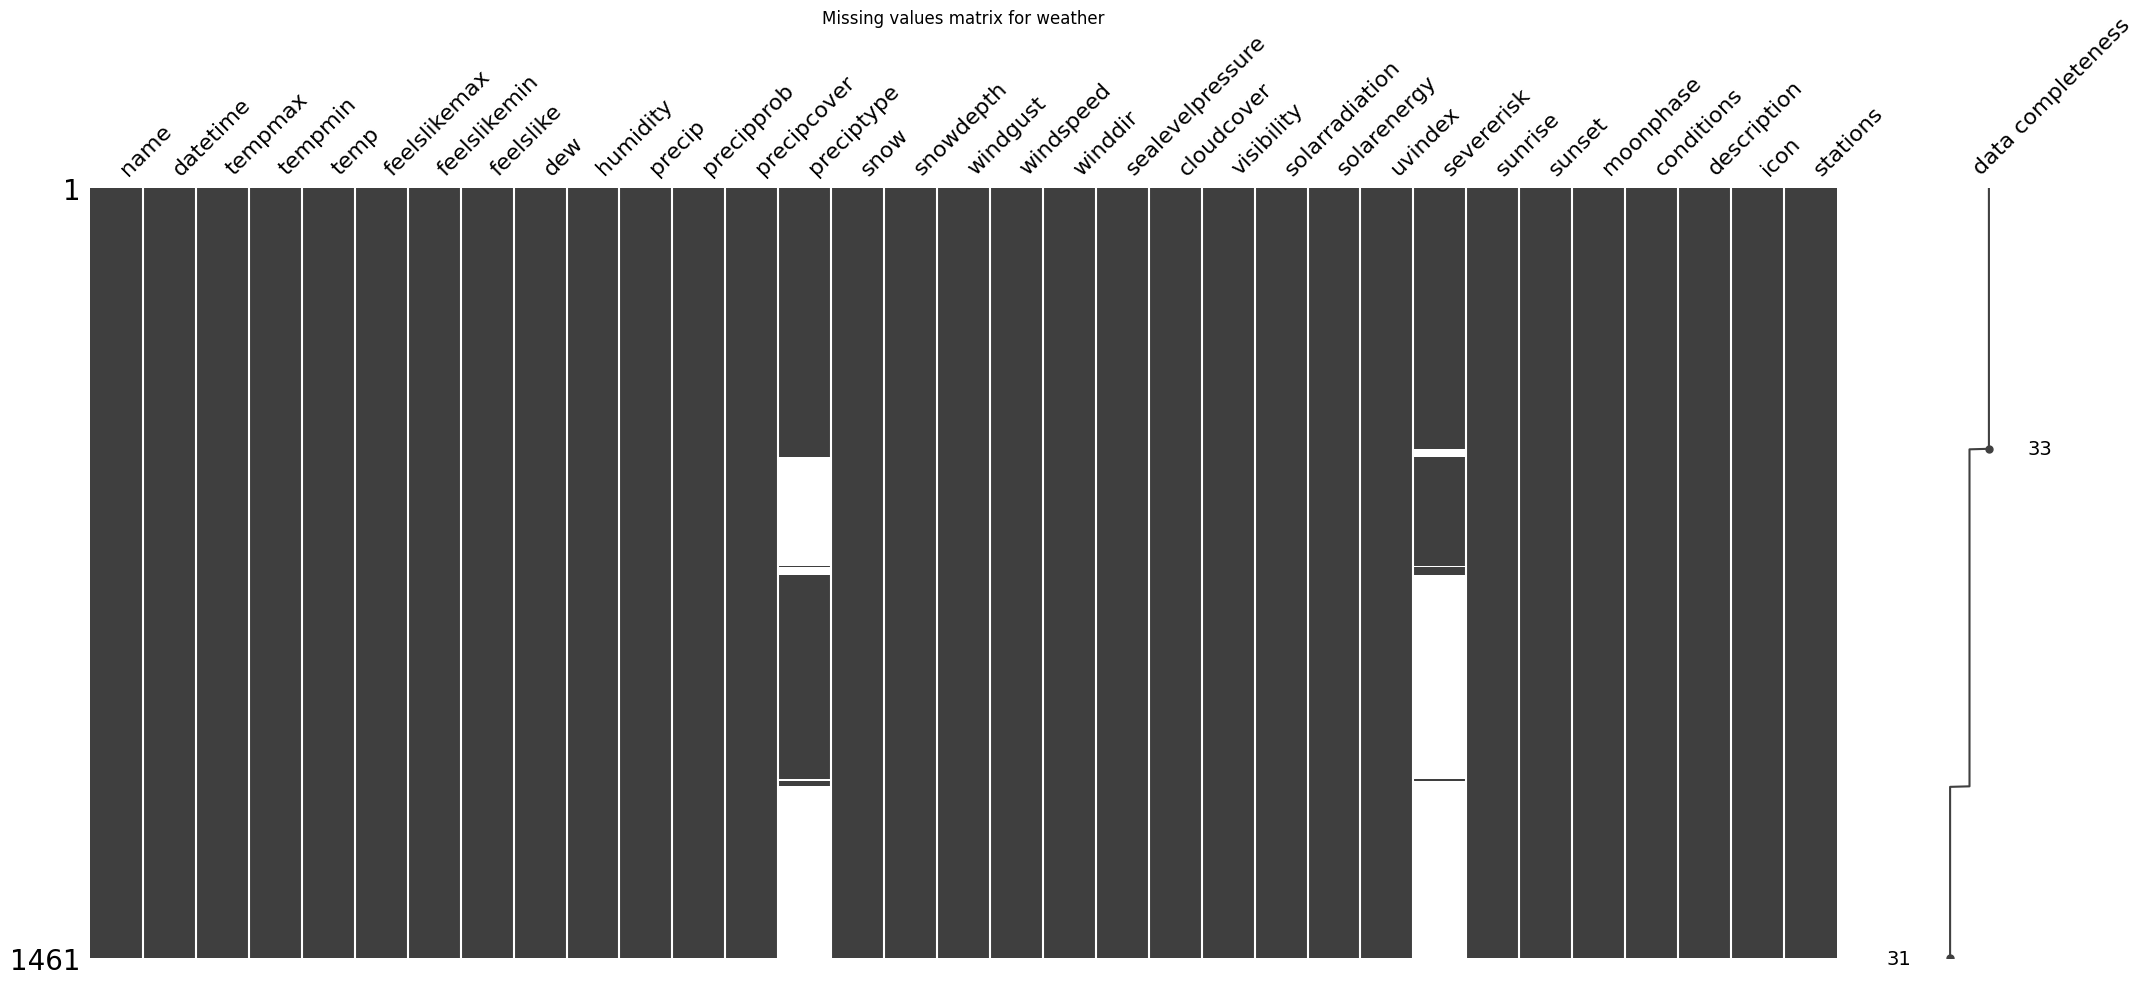

In [39]:
msno.matrix(weather, labels=True, sort="descending")
plt.title("Missing values matrix for weather")


In [41]:
weather['severerisk'] = weather['severerisk'].fillna(0)
weather['preciptype'] = weather['preciptype'].fillna("none")

In [ ]:
weather.isna().sum()

In [49]:
weather_date_duplicates = weather[weather.duplicated('datetime', keep=False)]
weather_date_duplicates.shape[0]

0

In [50]:
weather = weather.rename(columns={'datetime':'date'})

In [51]:
weather['date'] = weather['date'].str.split(' ').str[0]
weather['date'] = pd.to_datetime(weather['date'])

# Split Dataframe

In [62]:
moisture = weather[['date', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'preciptype']]
misc = weather[['date', 'sealevelpressure', 'cloudcover', 'visibility', 'severerisk', 'moonphase']]
sun = weather[['date', 'solarradiation', 'solarenergy', 'uvindex', 'sunrise', 'sunset']]
feelslike = weather[['date', 'feelslikemax', 'feelslikemin', 'feelslike']]
snow = weather[['date', 'snow', 'snowdepth']]
categorical = weather[['date', 'conditions', 'description', 'icon']]
temp = weather[['date', 'tempmax', 'tempmin', 'temp']]
wind = weather[['date', 'windgust', 'windspeed', 'winddir']]

In [65]:
temp

,date,tempmax,tempmin,temp
0,2020-01-01,42.1,35.8,39.5
1,2020-01-02,36.7,34.8,35.6
2,2020-01-03,43.9,36.0,40.8
3,2020-01-04,42.1,36.3,40.0
4,2020-01-05,41.3,32.0,37.5
...,...,...,...,...
1456,2023-12-27,40.2,32.5,37.2
1457,2023-12-28,47.0,38.5,44.2
1458,2023-12-29,46.6,42.9,44.8
1459,2023-12-30,42.8,39.2,41.2


In [67]:
save_dir = r'c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\data\clean\weather'

dfs = {
     'moisture':moisture, 
     'misc':misc, 
     'sun':sun, 
     'feelslike':feelslike, 
     'snow':snow, 
     'categorical':categorical, 
     'temp':temp, 
     'wind':wind
     }

for name, df in dfs.items():
    file_path = os.path.join(save_dir,f"{name}.pkl")
    save_object(file_path, df)